In [ ]:
# --- Repo-root bootstrap: keep relative paths (data/..., common.validation) working
# regardless of where Jupyter's working directory starts out ---
import os, sys
from pathlib import Path

_root = Path.cwd()
while not (_root / ".git").exists() and _root.parent != _root:
    _root = _root.parent
os.chdir(_root)
if str(_root) not in sys.path:
    sys.path.insert(0, str(_root))


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier

In [27]:
df = pd.read_csv('data/global_excel_resampled(Sheet1).csv',sep=";")

In [29]:
df.columns = df.columns.str.strip()
print(df['classe_name'].head())

0    Mixtes
1    Mixtes
2    Mixtes
3    Mixtes
4    Mixtes
Name: classe_name, dtype: str


In [30]:
target = 'classe_name'
features_cols = [col for col in df.columns if col.startswith('original_')] 

for col in features_cols:
    df[col] = pd.to_numeric(df[col].astype(str).str.replace(',', '.'), errors='coerce')

df_clean = df[features_cols + [target,"temps_inj","patient_num"]].dropna()

X = df_clean[features_cols]
y = df_clean[target].values 

scaler = StandardScaler()
X_scaled_array = scaler.fit_transform(X) 

df_scaled = pd.DataFrame(X_scaled_array, columns=features_cols)
df_scaled[target] = y 

print("Les données sont maintenant standardisées. Moyenne = ~0, Écart-type = 1")
display(df_scaled.head())

Les données sont maintenant standardisées. Moyenne = ~0, Écart-type = 1


,original_shape_Elongation,original_shape_Flatness,original_shape_LeastAxisLength,original_shape_MajorAxisLength,original_shape_Maximum2DDiameterColumn,original_shape_Maximum2DDiameterRow,original_shape_Maximum2DDiameterSlice,original_shape_Maximum3DDiameter,original_shape_MeshVolume,original_shape_MinorAxisLength,...,original_glcm_Imc2,original_glcm_InverseVariance,original_glcm_JointEnergy,original_glcm_JointEntropy,original_glcm_MCC,original_glcm_MaximumProbability,original_glcm_SumAverage,original_glcm_SumEntropy,original_glcm_SumSquares,classe_name
0,0.410176,0.327856,0.222194,0.072035,0.378202,0.006484,0.118941,0.234826,-0.262668,0.195834,...,0.515883,0.975988,-0.774453,0.727548,0.511294,-0.924511,0.208545,0.739039,-0.133622,Mixtes
1,0.603165,1.002576,0.426463,0.064853,0.220453,0.177762,0.198529,0.143790,-0.235755,0.229218,...,0.390421,0.869666,-0.486404,0.068088,0.406293,-0.490621,-0.315335,0.158286,-0.231469,Mixtes
2,-0.506199,0.216416,0.107838,0.002037,0.122945,-0.128999,0.118941,0.063015,-0.325572,-0.071353,...,0.897512,1.034600,-0.628011,0.358761,1.116084,-0.630609,0.140452,0.573550,-0.179764,Mixtes
3,-0.247968,0.752666,0.249634,-0.013639,0.053218,-0.091017,0.151409,-0.007987,-0.301301,-0.034431,...,0.969826,1.021443,-0.654232,0.427437,1.075319,-0.623604,0.088403,0.670130,-0.161286,Mixtes
4,0.329509,0.712028,0.258029,0.002870,0.129858,0.072113,0.236537,0.058022,-0.289686,0.101207,...,0.693159,1.173095,-0.622109,0.303961,0.697025,-0.671686,-0.116478,0.440626,-0.203972,Mixtes


In [31]:
len(df)-len(df_scaled)

0

In [32]:
df_scaled['patient_num'] = df_clean['patient_num'].values
df_scaled['temps_inj'] = df_clean['temps_inj'].values
df_scaled.to_csv('data/global_excel_resampled_scaled.csv', sep=";",index=False)

In [35]:
colonnes_a_exclure = ['classe_name', 'patient_num', 'temps_inj'] 

features_pca = [col for col in df_scaled.columns if col not in colonnes_a_exclure]

pca = PCA(n_components=2)
composantes_principales = pca.fit_transform(df_scaled[features_pca])

df_pca = pd.DataFrame(data=composantes_principales, columns=['PC1', 'PC2'])

df_pca['classe_name'] = df_scaled['classe_name'].values
df_pca['patient_num'] = df_scaled['patient_num'].values

variance = pca.explained_variance_ratio_ * 100
print(f"Information conservée : Axe 1 = {variance[0]:.1f}%, Axe 2 = {variance[1]:.1f}%")
print(f"Total de la variance expliquée : {sum(variance):.1f}%")

display(df_pca.head())

Information conservée : Axe 1 = 40.2%, Axe 2 = 22.1%
Total de la variance expliquée : 62.3%


,PC1,PC2,classe_name,patient_num
0,1.741578,1.077502,Mixtes,38
1,-0.989754,1.368893,Mixtes,38
2,0.679453,1.782115,Mixtes,37
3,0.688692,1.851123,Mixtes,37
4,0.096999,1.431308,Mixtes,37


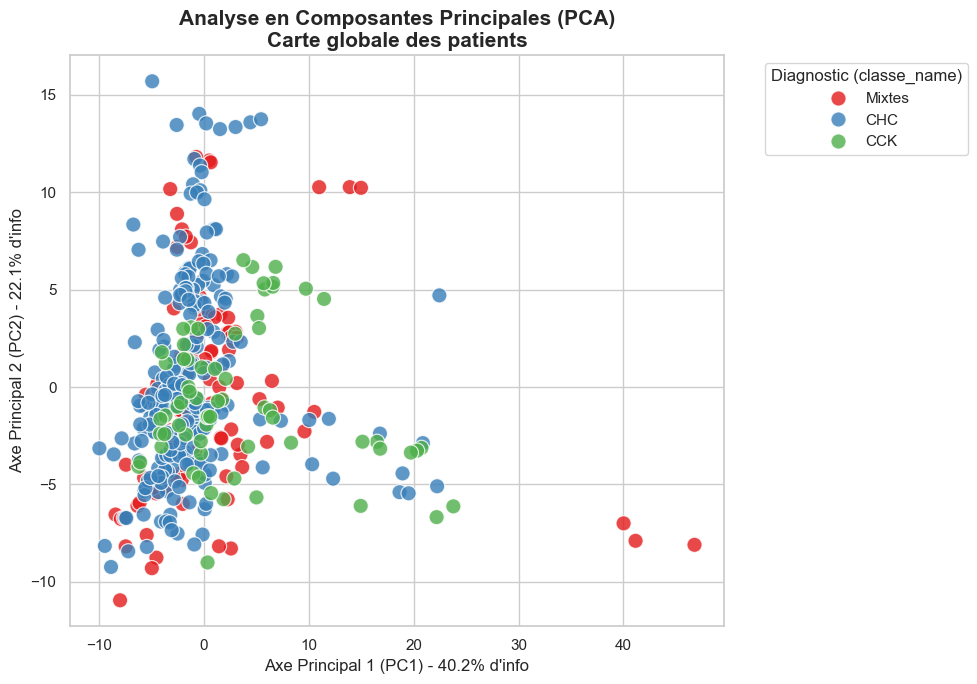

In [37]:
sns.set_theme(style="whitegrid", context="notebook")

plt.figure(figsize=(10, 7))

sns.scatterplot(
    data=df_pca,
    x='PC1',
    y='PC2',
    hue='classe_name', 
    palette='Set1',    
    s=120,             
    alpha=0.8,         
    edgecolor='white'  
)

plt.title("Analyse en Composantes Principales (PCA)\nCarte globale des patients", fontsize=15, fontweight='bold')
plt.xlabel(f"Axe Principal 1 (PC1) - {variance[0]:.1f}% d'info")
plt.ylabel(f"Axe Principal 2 (PC2) - {variance[1]:.1f}% d'info")

plt.legend(title="Diagnostic (classe_name)", bbox_to_anchor=(1.05, 1), loc='upper left')


plt.tight_layout()
plt.show()

In [5]:
df_descriptif = pd.read_csv("data/Descriptif_patients(Sheet1).csv", sep=";")
df_descriptif.head()

,classe_name,patient_num,Gender,Age_at_disease,Date_of_MRI,Date_of_surgery,Alpha_foetoprotein,Local_relapse,Date_of_local_relapse,Distant_relapse,Date_of_distant_relapse,Death,Date_of_death,Date_of_lost_of_FU,id
0,CCK,10,M,62.0,6/30/2015,7/1/2015,NaN,0.0,NaN,0.0,NaN,1.0,11/11/2015,NaN,1
1,CCK,11,F,57.0,5/22/2015,8/12/2015,6.1,0.0,NaN,0.0,NaN,0.0,NaN,6/8/2017,2
2,CCK,12,M,58.0,2/15/2016,4/13/2016,1.4,NaN,NaN,1.0,6/16/2016,1.0,3/30/2021,NaN,3
3,CCK,13,M,65.0,6/7/2016,8/5/2016,0.0,0.0,NaN,1.0,6/19/2017,1.0,4/25/2022,NaN,4
4,CCK,14,M,64.0,10/26/2016,3/16/2017,0.0,0.0,NaN,0.0,NaN,1.0,3/27/2017,NaN,5


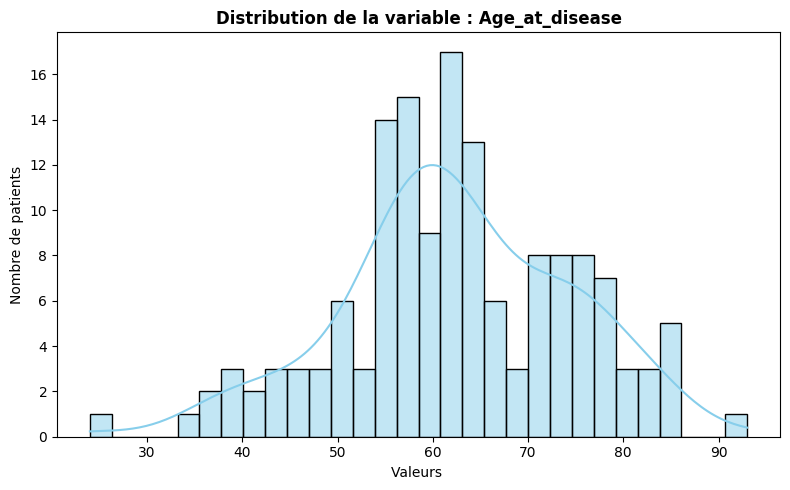

: 

In [ ]:
colonne_cible = 'Age_at_disease' 

plt.figure(figsize=(8, 5))

sns.histplot(
    data=df_descriptif, 
    x=colonne_cible, 
    kde=True,          
    color="skyblue",  
    bins=30            
)

plt.title(f"Distribution de la variable : {colonne_cible}", fontsize=12, fontweight='bold')
plt.xlabel("Valeurs ", fontsize=10)
plt.ylabel("Nombre de patients", fontsize=10)
plt.tight_layout()